# RL for Mathematical Reasoning in Small LLMs
**COMP 4453 Course Project** — Ahmad Shaker, Abdullah Elganainy, Karim Abousamra

This notebook compares **REINFORCE**, **PPO**, and **GRPO** on GSM8K using `Qwen/Qwen2.5-1.5B-Instruct` with LoRA.

### Current run profile
- Model: `Qwen/Qwen2.5-1.5B-Instruct`
- Steps per algorithm: `200`
- Batch size: `4`
- Generation length: `MAX_GEN_LEN = 256`
- Precision: bf16 + TF32 on GPU (no 4-bit quantization)


## 1. Install Dependencies


In [ ]:
!pip install -q torch transformers datasets peft accelerate matplotlib tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Device Setup
We detect CUDA availability and configure runtime behavior:
- **GPU available** → runs in bf16 with TF32 enabled
- **CPU only** → runs in float32 (slower)


In [26]:
import os
import re
import json
import time
import copy
from typing import List, Dict, Optional, Tuple
from contextlib import nullcontext

# Reduce VRAM fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

# ── Device detection ──
USE_GPU = torch.cuda.is_available()
DEVICE = "cuda" if USE_GPU else "cpu"
print(f"Device: {DEVICE}")
if USE_GPU:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected — running on CPU (will be slower, consider reducing NUM_TRAIN_STEPS)")


Device: cuda
GPU: NVIDIA GeForce RTX 4070
VRAM: 12.9 GB


## 3 — Configuration
All hyperparameters in one place. These are tuned for **laptop-friendly** runtimes:

| Setting | Laptop value | Full experiment value | Why |
|---------|-------------|----------------------|-----|
| Model | 0.5B | 1.5B | Fits CPU / low VRAM |
| Train steps | 50 | 1500 | ~15 min vs ~8 hours |
| Batch size | 2 | 4 | Less memory pressure |
| Max gen length | 256 | 512 | Faster generation |
| Eval samples | 50 | 200 | Quick feedback |

**To run the full experiment** (e.g. on Colab with a T4 GPU), change `MODEL_NAME` to `"Qwen/Qwen2.5-1.5B-Instruct"` and increase `NUM_TRAIN_STEPS` to 1500.

In [ ]:
# ══════════════════════════════════════════════════
# CONFIGURATION — edit these to scale up or down
# ══════════════════════════════════════════════════

# Model
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# LoRA
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Training
LEARNING_RATE = 5e-5
NUM_TRAIN_STEPS = 200
WARMUP_STEPS = 50
BATCH_SIZE = 4
MAX_PROMPT_LEN = 256
MAX_GEN_LEN = 256
TEMPERATURE = 0.8
GRAD_CLIP = 1.0
SEED = 42

# PPO-specific
PPO_CLIP_EPS = 0.2
PPO_EPOCHS = 2

# GRPO-specific
GRPO_GROUP_SIZE = 4
GRPO_KL_COEF = 0.01
GRPO_MAX_RETRIES = 1
GRPO_MAX_GEN_LEN = 256
GRPO_EVAL_EVERY = 100

# REINFORCE-specific
BASELINE_EMA = 0.85

# Evaluation
EVAL_EVERY = 100
EVAL_SAMPLES = 200
EVAL_BATCH_SIZE = 32

# Reward shaping
PARTIAL_CREDIT = 0.1

# Mixed precision
USE_AMP = True

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Configuration set!")
print(f"  Model: {MODEL_NAME}")
print(f"  Steps: {NUM_TRAIN_STEPS} | Batch: {BATCH_SIZE} | Eval every: {EVAL_EVERY}")
print(f"  LR: {LEARNING_RATE} | Warmup: {WARMUP_STEPS} | LoRA rank: {LORA_RANK} | AMP: {USE_AMP}")
print(f"  MAX_GEN_LEN: {MAX_GEN_LEN} | GRPO_GROUP_SIZE: {GRPO_GROUP_SIZE} | EVAL_BATCH_SIZE: {EVAL_BATCH_SIZE}")
print(f"  TF32: {torch.backends.cuda.matmul.allow_tf32}")
print(f"  SKIP_TRAINING: {SKIP_TRAINING}")


Configuration set!
  Model: Qwen/Qwen2.5-1.5B-Instruct
  Steps: 200 | Batch: 4 | Eval every: 100
  LR: 5e-05 | Warmup: 50 | LoRA rank: 16 | AMP: True
  MAX_GEN_LEN: 256 | GRPO_GROUP_SIZE: 4 | EVAL_BATCH_SIZE: 32
  TF32: True


## 4. Load GSM8K Dataset
GSM8K contains **8,792 grade-school math word problems** with human-written step-by-step solutions. Each answer ends with `#### <number>`. We extract that number as our gold answer for the reward function.

Example:
```
Q: Janet's ducks lay 16 eggs per day. She eats 3 and uses 4 to bake. She sells the rest at $2 each. How much does she make?
A: 16 - 3 - 4 = 9 eggs sold. 9 × $2 = $18. #### 18
```

In [29]:
print("Loading GSM8K dataset...")
dataset = load_dataset("openai/gsm8k", "main")

def extract_gold_answer(example):
    """Pull the number after '####' from the GSM8K answer field."""
    answer = example["answer"].split("####")[-1].strip()
    example["gold_answer"] = answer
    return example

train_data = dataset["train"].map(extract_gold_answer)
test_data = dataset["test"].map(extract_gold_answer)

print(f"  Train: {len(train_data)} problems")
print(f"  Test:  {len(test_data)} problems")
print(f"\nExample question: {train_data[0]['question'][:120]}...")
print(f"Gold answer: {train_data[0]['gold_answer']}")

Loading GSM8K dataset...
  Train: 7473 problems
  Test:  1319 problems

Example question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natali...
Gold answer: 72


## 5. Prompt Formatting & Reward Function

**Prompt template**: We wrap each GSM8K question in an instruction that tells the model to show step-by-step work and end with `####`.

**Reward function**: This is the key design choice from our proposal — we use a **rule-based exact-match reward** rather than a learned reward model:
- `+1.0` if the model's final number matches the gold answer
- `0.0` otherwise

This is simpler than the learned reward models used in RLHF (Ouyang et al., 2022) but works well for math where correctness is binary.

In [ ]:
def format_prompt(question: str) -> str:
    return (
        "Solve the problem below. Rules:\n"
        "- Do not restate the problem\n"
        "- No prose or filler phrases\n"
        "- Combine trivial steps\n"
        "- Format each step as: [step #] [operation] = [result]\n"
        "- End with exactly: #### followed immediately by the answer number\n\n"
        f"Question: {question}\n\n"
        "Solution:"
    )

def extract_answer(text: str) -> Optional[str]:
    """
    Extract the final numerical answer from model output.
    Tries several patterns in order of specificity:
      1. #### 42       (GSM8K format)
      2. answer is 42  (natural language)
      3. \\boxed{42}    (LaTeX math)
      4. last number in final sentence only (restricted fallback)
    """
    match = re.search(r"####\s*(-?[\d,]+\.?\d*)", text)
    if match:
        return match.group(1).replace(",", "").strip()

    match = re.search(r"(?:answer|result)\s*(?:is|=|:)\s*(-?[\d,]+\.?\d*)", text, re.IGNORECASE)
    if match:
        return match.group(1).replace(",", "").strip()

    match = re.search(r"\\boxed\{(-?[\d,]+\.?\d*)\}", text)
    if match:
        return match.group(1).replace(",", "").strip()

    sentences = re.split(r"[.!?\n]+", text.strip())
    last_sentence = sentences[-1] if sentences else ""
    numbers = re.findall(r"-?[\d,]+\.?\d*", last_sentence)
    if numbers:
        return numbers[-1].replace(",", "").strip()

    return None

def has_real_reasoning(text: str) -> bool:
    """
    Check whether the response contains reasoning, not just fluff.

    Uses three signals (any one is sufficient):
      1. Math operators — the model actually computed something
      2. Step-marking punctuation — numbered/bulleted steps
      3. Reasoning connectives — words that signal logical progression

    """
    has_math      = bool(re.search(r'[+\-*/=]', text))
    has_steps     = bool(re.search(r'(\n\s*[-*•]|\n\s*\d+[.)\s])', text))
    has_connective = bool(re.search(
        r'\b(therefore|thus|so|hence|final|total|equals|gives|result)\b',
        text, re.IGNORECASE
    ))
    return has_math or has_steps or has_connective


def compute_reward(generated_text: str, gold_answer: str) -> float:
    """
    Stepped reward function:

      1.0   correct final answer                        (main objective)
      0.1   wrong answer, but has #### AND real reasoning
      0.02  wrong answer, has #### only (no reasoning)
      0.02  wrong answer, has reasoning only (no ####)
      0.0   everything else
    """
    pred       = extract_answer(generated_text)
    has_format = "####" in generated_text
    has_reason = has_real_reasoning(generated_text)

    # Check for correct answer first
    if pred is not None:
        try:
            if abs(float(pred) - float(gold_answer.replace(',', '').strip())) < 1e-5:
                return 1.0
        except ValueError:
            if pred.strip() == gold_answer.strip():
                return 1.0

    # Partial credit — wrong answer
    if has_format and has_reason:
        return 0.1   # right behavior, wrong answer
    if has_format or has_reason:
        return 0.02  # partial behavior only
    return 0.0


# Sanity checks
print("Reward function tests:")
print(f"  [expect 1.0] correct answer with ####            = {compute_reward('16 - 3 - 4 = 9. #### 9', '9')}")
print(f"  [expect 0.1] wrong answer, has #### and steps    = {compute_reward('16 - 3 = 13, so #### 13', '18')}")
print(f"  [expect 0.1] wrong answer, has #### and operator = {compute_reward('16 - 3 = 13, so #### 20', '18')}")
print(f"  [expect 0.02] wrong answer, #### only no reasoning = {compute_reward('#### 20', '18')}")
print(f"  [expect 0.02] wrong answer, reasoning but no #### = {compute_reward('16 - 3 = 13, therefore 20', '18')}")
print(f"  [expect 0.0] fluff text, no #### no reasoning    = {compute_reward('the answer is the answer is the answer is', '18')}")
print(f"  [expect 0.0] empty/useless response              = {compute_reward('I am not sure', '18')}")


Reward function tests:
  [expect 1.0] correct answer with ####            = 1.0
  [expect 0.1] wrong answer, has #### and steps    = 0.1
  [expect 0.1] wrong answer, has #### and operator = 0.1
  [expect 0.02] wrong answer, #### only no reasoning = 0.02
  [expect 0.02] wrong answer, reasoning but no #### = 0.02
  [expect 0.0] fluff text, no #### no reasoning    = 0.0
  [expect 0.0] empty/useless response              = 0.0


## 6. Load Model with LoRA
We load `Qwen/Qwen2.5-1.5B-Instruct` and attach LoRA adapters so only a small fraction of parameters are trainable.

LoRA update form:
```
W_new = W_frozen + (A × B), where rank(A,B) << d
```

On GPU, this notebook runs in bf16 (no 4-bit quantization).

In [31]:
def load_model_and_tokenizer():
    """Load base model + LoRA adapters in bf16 (GPU) or fp32 (CPU)."""
    print(f"Loading {MODEL_NAME}...")

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, trust_remote_code=True, padding_side="left"
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model_kwargs = {"trust_remote_code": True}

    if USE_GPU:
        # bf16 directly — Qwen 1.5B only needs ~3GB VRAM, no quantization needed
        model_kwargs["torch_dtype"] = torch.bfloat16
        model_kwargs["device_map"] = "auto"
        print("  Using bf16 (GPU)")
    else:
        model_kwargs["torch_dtype"] = torch.float32
        print("  Using float32 (CPU)")

    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **model_kwargs)

    if not USE_GPU:
        model = model.to(DEVICE)

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGETS,
        bias="none",
    )
    model = get_peft_model(model, lora_config)

    trainable, total = model.get_nb_trainable_parameters()
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    return model, tokenizer


base_model, tokenizer = load_model_and_tokenizer()

_initial_lora_state = {
    k: v.detach().clone()
    for k, v in base_model.named_parameters()
    if v.requires_grad
}

def reset_lora_weights(model):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in _initial_lora_state:
                param.copy_(_initial_lora_state[name])
    print("  LoRA weights reset to initial state")
    return model


def compute_ref_log_probs(model, prompts, responses):
    current_state = {
        k: v.detach().clone()
        for k, v in model.named_parameters()
        if k in _initial_lora_state
    }

    try:
        with torch.no_grad():
            for name, param in model.named_parameters():
                if name in _initial_lora_state:
                    param.copy_(_initial_lora_state[name])
        model.eval()
        with torch.no_grad():
            ref_lp = compute_log_probs(model, prompts, responses)
    finally:
        model.train()
        with torch.no_grad():
            for name, param in model.named_parameters():
                if name in current_state:
                    param.copy_(current_state[name])

    return ref_lp


print("Model loaded (bf16, no quantization).")


Loading Qwen/Qwen2.5-1.5B-Instruct...
  Using bf16 (GPU)


Loading weights: 100%|██████████| 338/338 [00:03<00:00, 105.15it/s]


  Trainable: 4,358,144 / 1,548,072,448 (0.28%)
Model loaded (bf16, no quantization).


## 7. Generation & Log-Probability Helpers
These two utility functions are used by all three algorithms:

1. **`generate_responses`** — Given prompts, sample completions from the current policy using temperature sampling. Returns the generated text (with the prompt stripped off).

2. **`compute_log_probs`** — Given prompt-response pairs, compute `log π_θ(response | prompt)` — the sum of per-token log probabilities under the current model. This is the core quantity in the policy gradient:
   ```
   ∇J(θ) = E[ A(s,a) · ∇ log π_θ(a|s) ]
   ```

In [32]:
@torch.no_grad()
def _generate_batch(model, prompts: List[str], num_return: int = 1, max_new_tokens: Optional[int] = None):
    """Raw batched generation — internal helper, call generate_responses instead."""
    inputs = tokenizer(
        prompts, return_tensors="pt",
        max_length=MAX_PROMPT_LEN, truncation=True,
        padding=True
    ).to(model.device)

    if USE_AMP:
        ctx = torch.amp.autocast("cuda" if USE_GPU else "cpu", dtype=torch.bfloat16)
    else:
        ctx = nullcontext()

    with ctx:
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens or MAX_GEN_LEN,
            temperature=TEMPERATURE,
            do_sample=True,
            num_return_sequences=num_return,
            pad_token_id=tokenizer.pad_token_id,
            repetition_penalty=1.1,
        )

    prompt_len = inputs["input_ids"].shape[1]
    all_responses = []
    for i in range(len(prompts)):
        responses = []
        for j in range(num_return):
            idx = i * num_return + j
            gen_tokens = outputs[idx][prompt_len:]
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
            responses.append(text)
        all_responses.append(responses)
    return all_responses


@torch.no_grad()
def generate_responses(model, prompts: List[str], num_return: int = 1, max_retries: int = 2, max_new_tokens: Optional[int] = None) -> List[List[str]]:
    # First pass — generate everything in one batched call
    all_responses = _generate_batch(model, prompts, num_return, max_new_tokens=max_new_tokens)

    # Identify which (prompt_idx, response_idx) pairs are missing ####
    for retry in range(max_retries):
        retry_prompt_indices = []  # which prompts need a retry
        retry_response_slots = []  # which response slot within that prompt

        for i, responses in enumerate(all_responses):
            for j, resp in enumerate(responses):
                if "####" not in resp:
                    retry_prompt_indices.append(i)
                    retry_response_slots.append(j)

        if not retry_prompt_indices:
            break  # all responses have ####, done

        # Batch the retries — only regenerate the malformed ones
        retry_prompts = [prompts[i] for i in retry_prompt_indices]
        retry_results = _generate_batch(model, retry_prompts, num_return=1, max_new_tokens=max_new_tokens)

        for idx, (prompt_i, resp_j) in enumerate(zip(retry_prompt_indices, retry_response_slots)):
            all_responses[prompt_i][resp_j] = retry_results[idx][0]

    return all_responses


def compute_log_probs(model, prompts: List[str], responses: List[str]) -> torch.Tensor:
    full_texts = [p + r for p, r in zip(prompts, responses)]

    prompt_encodings = tokenizer(
        prompts, max_length=MAX_PROMPT_LEN, truncation=True
    )
    prompt_lengths = [len(ids) for ids in prompt_encodings["input_ids"]]

    inputs = tokenizer(
        full_texts, return_tensors="pt",
        max_length=MAX_PROMPT_LEN + MAX_GEN_LEN, truncation=True,
        padding=True
    ).to(model.device)

    if USE_AMP:
        ctx = torch.amp.autocast("cuda" if USE_GPU else "cpu", dtype=torch.bfloat16)
    else:
        ctx = nullcontext()

    with ctx:
        outputs = model(**inputs)
    logits = outputs.logits

    log_probs_list = []
    for i, plen in enumerate(prompt_lengths):
        shift_logits = logits[i, plen - 1:-1, :]
        shift_labels = inputs["input_ids"][i, plen:]
        mask = (shift_labels != tokenizer.pad_token_id).float()
        # Avoid upcasting full logits tensor; upcast only this slice for stability.
        lp = torch.nn.functional.log_softmax(shift_logits.float(), dim=-1)
        token_lp = lp.gather(1, shift_labels.unsqueeze(-1)).squeeze(-1)
        total = (token_lp * mask).sum()
        log_probs_list.append(total.unsqueeze(0))

    return torch.cat(log_probs_list)


print("Helper functions defined (batched + #### format enforcement with retry).")


Helper functions defined (batched + #### format enforcement with retry).


## 8. Evaluation Function
We evaluate the model by generating answers for a random subset of the GSM8K test set and checking exact match against the gold answers. This gives us our **accuracy** metric.

We run evaluation every `EVAL_EVERY` training steps to track how each algorithm improves over time.

In [33]:
@torch.no_grad()
def evaluate(model, eval_indices: np.ndarray) -> Dict:
    """
    Evaluate accuracy on a fixed subset of GSM8K test set.
    """
    model.eval()
    correct = 0

    for batch_start in tqdm(range(0, len(eval_indices), EVAL_BATCH_SIZE), desc="Evaluating", leave=False):
        batch_indices = eval_indices[batch_start:batch_start + EVAL_BATCH_SIZE]
        batch_examples = [test_data[int(idx)] for idx in batch_indices]
        prompts = [format_prompt(ex["question"]) for ex in batch_examples]
        golds = [ex["gold_answer"] for ex in batch_examples]

        inputs = tokenizer(prompts, return_tensors="pt", max_length=MAX_PROMPT_LEN, truncation=True, padding=True).to(model.device)

        if USE_AMP:
            ctx = torch.amp.autocast("cuda" if USE_GPU else "cpu", dtype=torch.bfloat16)
        else:
            ctx = nullcontext()

        with ctx:
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_GEN_LEN,
                do_sample=False, #Determinisitic
                pad_token_id=tokenizer.pad_token_id,
                repetition_penalty=1.1,
            )

        prompt_len = inputs["input_ids"].shape[1]
        for i, gold in enumerate(golds):
            gen_tokens = outputs[i][prompt_len:]
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
            correct += (1.0 if compute_reward(text, gold) == 1.0 else 0.0)

    accuracy = correct / len(eval_indices)
    model.train()
    return {"accuracy": accuracy, "correct": int(correct), "total": len(eval_indices)}


EVAL_INDICES = np.random.choice(len(test_data), min(EVAL_SAMPLES, len(test_data)), replace=False)
print(f"Fixed eval subset: {len(EVAL_INDICES)} problems (indices locked in for all algorithms)")
print("Evaluation function defined (deterministic greedy decoding).")


Fixed eval subset: 200 problems (indices locked in for all algorithms)
Evaluation function defined (deterministic greedy decoding).


## 9. Baseline Model Evaluation
Before any RL training, let's see how the base model (with random LoRA weights) performs on GSM8K. This gives us a **floor** to compare all three algorithms against.

In [ ]:
print("Evaluating base model (before any RL training)...")
base_result = evaluate(base_model, EVAL_INDICES)
print(f"Base model accuracy: {base_result['accuracy']:.3f} ({base_result['correct']}/{base_result['total']})")

# Sample output — greedy decoding, full response
sample_q = train_data[0]["question"]
sample_prompt = format_prompt(sample_q)

inputs = tokenizer(
    [sample_prompt], return_tensors="pt",
    max_length=MAX_PROMPT_LEN, truncation=True, padding=True
).to(base_model.device)

with torch.no_grad():
    output = base_model.generate(
        **inputs,
        max_new_tokens=MAX_GEN_LEN,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        repetition_penalty=1.1,
    )

prompt_len = inputs["input_ids"].shape[1]
sample_resp = tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True)

print(f"\nSample question: {sample_q}")
print(f"\nModel response:\n{sample_resp}")
print(f"\nGold answer: {train_data[0]['gold_answer']}")
print(f"Extracted answer: {extract_answer(sample_resp)}")
print(f"Reward: {compute_reward(sample_resp, train_data[0]['gold_answer'])}")

Evaluating base model (before any RL training)...


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Base model accuracy: 0.505 (101/200)

Sample question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

Model response:
 
1) Calculate how many clips Natalia sold in May: 
   - She sold half as many clips in May as she did in April.
   - Number of clips sold in April: 48
   - Number of clips sold in May: \( \frac{48}{2} = 24 \)

2) Add the number of clips sold in April and May together:
   - Total number of clips sold in April and May: \( 48 + 24 = 72 \)

#### Answer: 72

Gold answer: 72
Extracted answer: 72
Reward: 1.0


---
## 10. REINFORCE with Baseline

In [34]:
def train_reinforce(model):
    print("\n" + "=" * 55)
    print("  REINFORCE with Baseline")
    print("=" * 55)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    # Warmup + cosine annealing
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_STEPS
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_TRAIN_STEPS - WARMUP_STEPS, eta_min=LEARNING_RATE * 0.1
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_STEPS]
    )

    baseline = None      # initialized from first batch (not 0.0)
    log_data = []        # evaluation checkpoints
    rewards_history = [] # per-step mean rewards

    model.train()
    pbar = tqdm(range(NUM_TRAIN_STEPS), desc="REINFORCE")

    for step in pbar:
        # Sample a batch of math problems
        indices = np.random.choice(len(train_data), BATCH_SIZE)
        batch = [train_data[int(i)] for i in indices]
        prompts = [format_prompt(ex["question"]) for ex in batch]
        golds = [ex["gold_answer"] for ex in batch]

        # Generate one response per prompt
        responses_batch = generate_responses(model, prompts, num_return=1)
        responses = [r[0] for r in responses_batch]

        # Compute rewards (exact-match + reward shaping)
        rewards = torch.tensor(
            [compute_reward(r, g) for r, g in zip(responses, golds)],
            dtype=torch.float32, device=model.device
        )

        # Update EMA baseline (initialize from first batch for fast warmup)
        mean_r = rewards.mean().item()
        if baseline is None:
            baseline = mean_r
        else:
            baseline = BASELINE_EMA * baseline + (1 - BASELINE_EMA) * mean_r

        # Advantages = reward - baseline, normalized for stability
        advantages = rewards - baseline
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Compute log π(response | prompt)
        log_probs = compute_log_probs(model, prompts, responses)

        # REINFORCE loss: -E[advantage * log_prob]
        loss = -(advantages * log_probs).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        rewards_history.append(mean_r)
        pbar.set_postfix({"reward": f"{mean_r:.2f}", "baseline": f"{baseline:.3f}"})

        # Periodic evaluation
        if (step + 1) % EVAL_EVERY == 0:
            result = evaluate(model, EVAL_INDICES)
            print(f"  Step {step+1}: accuracy = {result['accuracy']:.3f}")
            log_data.append({
                "step": step + 1, "algo": "reinforce",
                "avg_reward": float(np.mean(rewards_history[-20:])),
                "eval_accuracy": result["accuracy"],
            })

    return log_data, rewards_history

print("REINFORCE trainer defined.")

REINFORCE trainer defined.


---
## 11. PPO (Proximal Policy Optimization)

In [35]:
def train_ppo(model):
    print("\n" + "=" * 55)
    print("  PPO (Proximal Policy Optimization)")
    print("=" * 55)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_STEPS
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_TRAIN_STEPS - WARMUP_STEPS, eta_min=LEARNING_RATE * 0.1
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_STEPS]
    )

    value_baseline = None
    log_data = []
    rewards_history = []

    model.train()
    pbar = tqdm(range(NUM_TRAIN_STEPS), desc="PPO")

    for step in pbar:
        indices = np.random.choice(len(train_data), BATCH_SIZE)
        batch = [train_data[int(i)] for i in indices]
        prompts = [format_prompt(ex["question"]) for ex in batch]
        golds = [ex["gold_answer"] for ex in batch]

        responses_batch = generate_responses(model, prompts, num_return=1)
        responses = [r[0] for r in responses_batch]

        rewards = torch.tensor(
            [compute_reward(r, g) for r, g in zip(responses, golds)],
            dtype=torch.float32, device=model.device
        )

        mean_r = rewards.mean().item()
        if value_baseline is None:
            value_baseline = mean_r
        else:
            value_baseline = 0.85 * value_baseline + 0.15 * mean_r

        advantages = rewards - value_baseline
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        with torch.no_grad():
            old_log_probs = compute_log_probs(model, prompts, responses).detach()

        for epoch in range(PPO_EPOCHS):
            new_log_probs = compute_log_probs(model, prompts, responses)
            ratio = torch.exp(new_log_probs - old_log_probs)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - PPO_CLIP_EPS, 1 + PPO_CLIP_EPS) * advantages
            loss = -torch.min(surr1, surr2).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        scheduler.step()

        rewards_history.append(mean_r)
        pbar.set_postfix({"reward": f"{mean_r:.2f}", "loss": f"{loss.item():.3f}"})

        if (step + 1) % EVAL_EVERY == 0:
            result = evaluate(model, EVAL_INDICES)
            print(f"  Step {step+1}: accuracy = {result['accuracy']:.3f}")
            log_data.append({
                "step": step + 1, "algo": "ppo",
                "avg_reward": float(np.mean(rewards_history[-20:])),
                "eval_accuracy": result["accuracy"],
            })

    return log_data, rewards_history

print("PPO trainer defined.")


PPO trainer defined.


---
## 12. GRPO (Group Relative Policy Optimization)

In [36]:
def train_grpo(model):
    print("\n" + "=" * 55)
    print("  GRPO (Group Relative Policy Optimization)")
    print("=" * 55)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    # Warmup + cosine annealing
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_STEPS
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_TRAIN_STEPS - WARMUP_STEPS, eta_min=LEARNING_RATE * 0.1
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_STEPS]
    )

    log_data = []
    rewards_history = []

    model.train()
    pbar = tqdm(range(NUM_TRAIN_STEPS), desc="GRPO")
    
    grpo_batch_size = min(BATCH_SIZE, 4)

    for step in pbar:
        indices = np.random.choice(len(train_data), grpo_batch_size)
        batch = [train_data[int(i)] for i in indices]
        prompts = [format_prompt(ex["question"]) for ex in batch]
        golds = [ex["gold_answer"] for ex in batch]

        # Generate a GROUP of K responses per prompt (GRPO-specific speed settings)
        all_responses = generate_responses(
            model,
            prompts,
            num_return=GRPO_GROUP_SIZE,
            max_retries=GRPO_MAX_RETRIES,
            max_new_tokens=GRPO_MAX_GEN_LEN,
        )

        batch_rewards = []
        valid_groups = []

        # Pass 1: compute rewards/advantages + reference log-probs (no autograd graph kept)
        for prompt, responses, gold in zip(prompts, all_responses, golds):
            group_rewards = torch.tensor(
                [compute_reward(r, gold) for r in responses],
                dtype=torch.float32, device=model.device
            )
            batch_rewards.extend(group_rewards.tolist())

            mean_r = group_rewards.mean()
            std_r = group_rewards.std()

          
            if std_r < 1e-8:
                if mean_r > 1e-8:
                    continue  # e.g. all got 1.0 — nothing to learn here
                else:
                    # All zero: push away uniformly
                    advantages = torch.full_like(group_rewards, -1.0)
                    prompts_k = [prompt] * GRPO_GROUP_SIZE
                    ref_log_probs = compute_ref_log_probs(model, prompts_k, responses).detach()
                    valid_groups.append((prompts_k, responses, advantages.detach(), ref_log_probs))
                    continue

            advantages = (group_rewards - mean_r) / (std_r + 1e-8)
            prompts_k = [prompt] * GRPO_GROUP_SIZE

          
            ref_log_probs = compute_ref_log_probs(model, prompts_k, responses).detach()
            valid_groups.append((prompts_k, responses, advantages.detach(), ref_log_probs))

        # Pass 2: gradient accumulation across groups (same objective, lower peak VRAM)
        if valid_groups:
            optimizer.zero_grad(set_to_none=True)
            num_groups = len(valid_groups)

            for prompts_k, responses, advantages, ref_log_probs in valid_groups:
                log_probs = compute_log_probs(model, prompts_k, responses)
                pg_loss = -(advantages * log_probs).mean()
                kl_penalty = (log_probs - ref_log_probs).mean()
                group_loss = pg_loss + GRPO_KL_COEF * kl_penalty

                # Average over groups while freeing each group graph immediately.
                (group_loss / num_groups).backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        if valid_groups:
            scheduler.step()

        mean_r = np.mean(batch_rewards) if batch_rewards else 0.0
        rewards_history.append(mean_r)
        pbar.set_postfix({"reward": f"{mean_r:.2f}"})

        if (step + 1) % GRPO_EVAL_EVERY == 0:
            result = evaluate(model, EVAL_INDICES)
            acc = result["accuracy"]
            print(f"  Step {step+1}: accuracy = {acc:.3f}")
            log_data.append({
                "step": step + 1, "algo": "grpo",
                "avg_reward": float(np.mean(rewards_history[-20:])),
                "eval_accuracy": acc,
            })

    return log_data, rewards_history

print("GRPO trainer defined.")

GRPO trainer defined.


---
## 13. Run All Three Algorithms


In [13]:
all_results = {}

# Save directory for LoRA adapter checkpoints + tokenizer files
save_root = "saved_models"
os.makedirs(save_root, exist_ok=True)

def cleanup_gpu(label: str = "cleanup"):
    if USE_GPU:
        import gc
        gc.collect()
        torch.cuda.empty_cache()
        print(f"VRAM after {label}: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated")

# ── Algorithm 1: REINFORCE ──
print("\nResetting LoRA weights for REINFORCE...")
reset_lora_weights(base_model)
start = time.time()
log_r, rewards_r = train_reinforce(base_model)
elapsed_r = time.time() - start
all_results["reinforce"] = {"log": log_r, "rewards": rewards_r, "time": elapsed_r}
print(f"REINFORCE done in {elapsed_r/60:.1f} min")

reinforce_dir = os.path.join(save_root, "reinforce_lora")
base_model.save_pretrained(reinforce_dir)
tokenizer.save_pretrained(reinforce_dir)
print(f"Saved REINFORCE checkpoint to {reinforce_dir}")

cleanup_gpu("REINFORCE")



Resetting LoRA weights for REINFORCE...
  LoRA weights reset to initial state

  REINFORCE with Baseline


REINFORCE:  50%|█████     | 100/200 [32:06<1:33:00, 55.80s/it, reward=1.00, baseline=0.777]

  Step 100: accuracy = 0.590


REINFORCE: 100%|██████████| 200/200 [1:01:52<00:00, 18.56s/it, reward=0.55, baseline=0.826]


  Step 200: accuracy = 0.530
REINFORCE done in 61.9 min
Saved REINFORCE checkpoint to saved_models\reinforce_lora
VRAM after REINFORCE: 3.2 GB allocated


In [14]:
# ── Algorithm 2: PPO ──
print("\nResetting LoRA weights for PPO...")
reset_lora_weights(base_model)
start = time.time()
log_p, rewards_p = train_ppo(base_model)
elapsed_p = time.time() - start
all_results["ppo"] = {"log": log_p, "rewards": rewards_p, "time": elapsed_p}
print(f"PPO done in {elapsed_p/60:.1f} min")

ppo_dir = os.path.join(save_root, "ppo_lora")
base_model.save_pretrained(ppo_dir)
tokenizer.save_pretrained(ppo_dir)
print(f"Saved PPO checkpoint to {ppo_dir}")

cleanup_gpu("PPO")



Resetting LoRA weights for PPO...
  LoRA weights reset to initial state

  PPO (Proximal Policy Optimization)


PPO:  50%|█████     | 100/200 [30:27<1:29:25, 53.66s/it, reward=0.53, loss=-0.173]

  Step 100: accuracy = 0.470


PPO: 100%|██████████| 200/200 [1:02:37<00:00, 18.79s/it, reward=0.10, loss=0.410] 


  Step 200: accuracy = 0.540
PPO done in 62.6 min
Saved PPO checkpoint to saved_models\ppo_lora
VRAM after PPO: 3.2 GB allocated


In [21]:
# ── Algorithm 3: GRPO ──
print("\nResetting LoRA weights for GRPO...")
reset_lora_weights(base_model)
start = time.time()
log_g, rewards_g = train_grpo(base_model)
elapsed_g = time.time() - start
all_results["grpo"] = {"log": log_g, "rewards": rewards_g, "time": elapsed_g}
print(f"GRPO done in {elapsed_g/60:.1f} min")

grpo_dir = os.path.join(save_root, "grpo_lora")
base_model.save_pretrained(grpo_dir)
tokenizer.save_pretrained(grpo_dir)
print(f"Saved GRPO checkpoint to {grpo_dir}")

cleanup_gpu("GRPO")



Resetting LoRA weights for GRPO...
  LoRA weights reset to initial state

  GRPO (Group Relative Policy Optimization)


GRPO:  50%|█████     | 100/200 [35:17<1:01:51, 37.12s/it, reward=0.78]

  Step 100: accuracy = 0.575


GRPO: 100%|██████████| 200/200 [1:04:26<00:00, 19.33s/it, reward=0.78]


  Step 200: accuracy = 0.615
GRPO done in 64.4 min
Saved GRPO checkpoint to saved_models\grpo_lora
VRAM after GRPO: 3.2 GB allocated


---
## 14. Comparison Plots

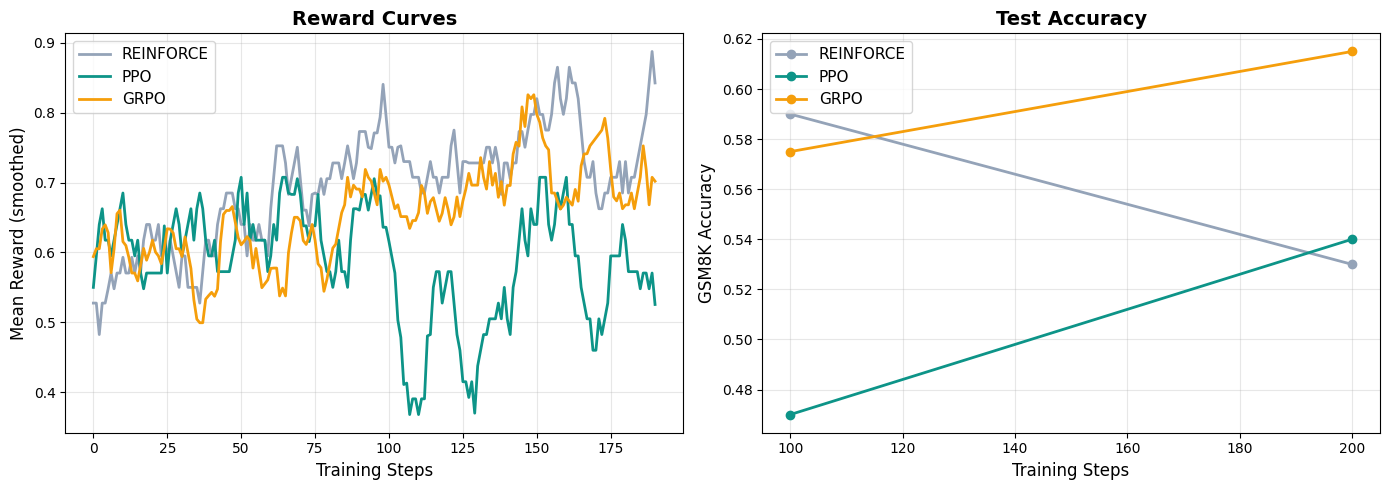

Plots saved to comparison_plots.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"reinforce": "#94A3B8", "ppo": "#0D9488", "grpo": "#F59E0B"}
labels = {"reinforce": "REINFORCE", "ppo": "PPO", "grpo": "GRPO"}

# ── Left: Reward curves ──
ax1 = axes[0]
for algo, data in all_results.items():
    rewards = data["rewards"]
    window = min(10, len(rewards))  # smoothing window
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode="valid")
        ax1.plot(smoothed, label=labels[algo], color=colors[algo], linewidth=2)
    else:
        ax1.plot(rewards, label=labels[algo], color=colors[algo], linewidth=2)

ax1.set_xlabel("Training Steps", fontsize=12)
ax1.set_ylabel("Mean Reward (smoothed)", fontsize=12)
ax1.set_title("Reward Curves", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# ── Right: Accuracy over time ──
ax2 = axes[1]
for algo, data in all_results.items():
    if data["log"]:
        steps = [d["step"] for d in data["log"]]
        accs = [d["eval_accuracy"] for d in data["log"]]
        ax2.plot(steps, accs, "o-", label=labels[algo], color=colors[algo], linewidth=2, markersize=6)

ax2.set_xlabel("Training Steps", fontsize=12)
ax2.set_ylabel("GSM8K Accuracy", fontsize=12)
ax2.set_title("Test Accuracy", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to comparison_plots.png")

## 15. Final Summary Table
Print a side-by-side comparison of all three algorithms across our four evaluation metrics.

In [ ]:
print("\n" + "=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"  {'Algorithm':<14} {'Accuracy':>10} {'Avg Reward':>12} {'Time (min)':>12}")
print("-" * 65)

print(f"  {'Baseline':<14} {base_result['accuracy']:>10.3f} {'N/A':>12} {'N/A':>12}")

for algo, data in all_results.items():
    final_acc = data["log"][-1]["eval_accuracy"] if data["log"] else 0
    final_rew = data["log"][-1]["avg_reward"] if data["log"] else 0
    t = data["time"] / 60
    if data.get("skipped"):
        print(f"  {algo.upper():<14} {final_acc:>10.3f} {'N/A':>12} {t:>12.1f}")
    else:
        print(f"  {algo.upper():<14} {final_acc:>10.3f} {final_rew:>12.3f} {t:>12.1f}")



  FINAL RESULTS SUMMARY
  Algorithm        Accuracy   Avg Reward   Time (min)
-----------------------------------------------------------------
  Baseline            0.505          N/A          N/A
  REINFORCE           0.530        0.786         61.9
  PPO                 0.540        0.571         62.6
  GRPO                0.615        0.764         72.2


---
## Summary

This notebook compares REINFORCE, PPO, and GRPO on GSM8K with a shared LoRA setup.

### Current local config
- `MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"`
- `NUM_TRAIN_STEPS = 200`
- `BATCH_SIZE = 4`
- `MAX_PROMPT_LEN = 256`
- `MAX_GEN_LEN = 256`
- `GRPO_GROUP_SIZE = 4`

### References
- Williams, R.J. (1992). REINFORCE — *Machine Learning* 8(3-4)
- Schulman et al. (2017). PPO — *arXiv:1707.06347*
- Shao et al. (2024). DeepSeekMath / GRPO — *arXiv:2402.03300*
- Cobbe et al. (2021). GSM8K — *arXiv:2110.14168*